#project objective
To develop  a deep learning classification model that predicts whether a machine is likely to experience a failure 
based on its operational and sensor-related features


In [ ]:
#Import Libraries
import numpy as np
import pandas as pd


In [4]:
#Load the dataset
df = pd.read_csv("data/ai4i2020.csv")

In [5]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
#understand the dataset
df.shape

(10000, 14)

In [7]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [9]:
#data cleaning
print(df.isnull().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [10]:
print(df.duplicated().sum())

0


In [11]:
#preprocessing
print(df.columns)


Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')


In [12]:
df=df.drop(columns = ['UDI','Product ID', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'])

In [13]:
#EDA
import matplotlib.pyplot as plt
import seaborn as sns



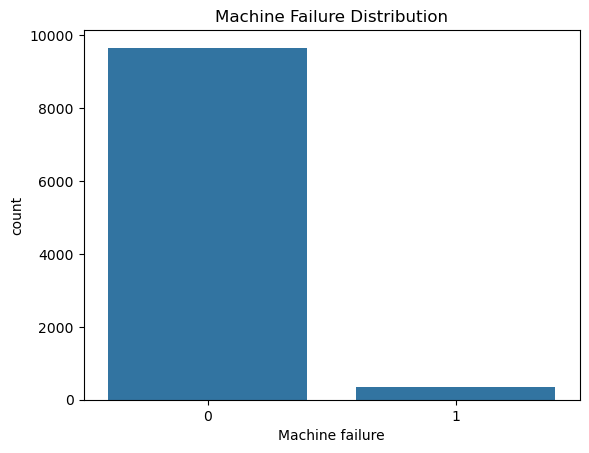

In [14]:
sns.countplot(x = 'Machine failure',data = df)
plt.title("Machine Failure Distribution")
plt.show()

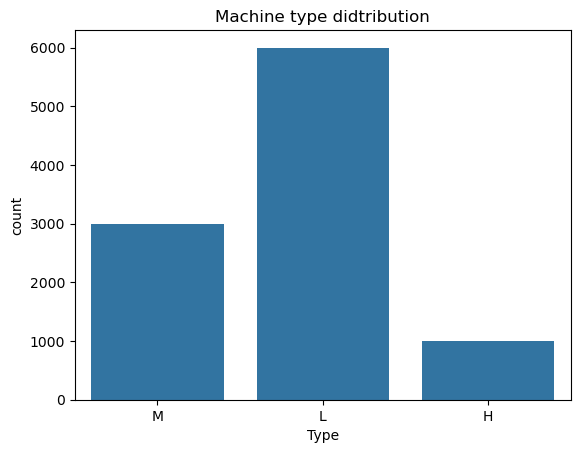

In [15]:
#count plot for type
sns.countplot(x = "Type",data=df)
plt.title("Machine type didtribution")
plt.show()

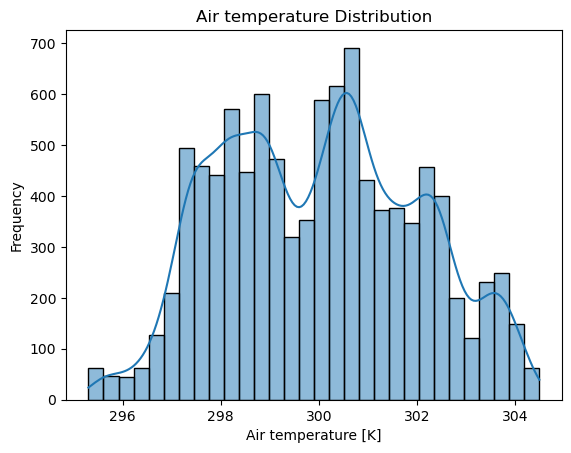

In [16]:
#histogram for air temperature 
sns.histplot(df['Air temperature [K]'],bins = 30,kde = True)
plt.title("Air temperature Distribution")
plt.xlabel("Air temperature [K]")
plt.ylabel("Frequency")
plt.show()

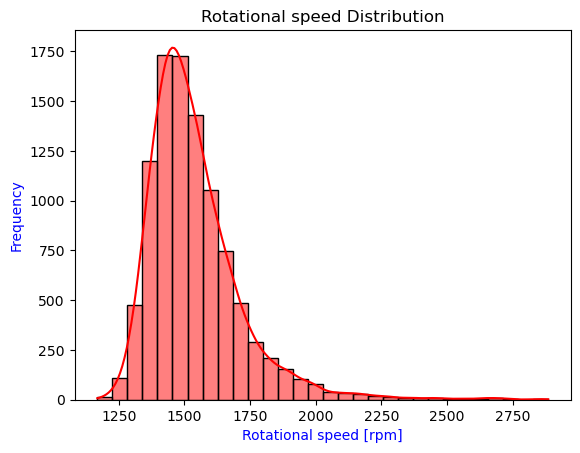

In [17]:
#histogram for rotational speed
sns.histplot(df['Rotational speed [rpm]'],bins = 30, kde = True,color = 'r')
plt.title('Rotational speed Distribution' )
plt.xlabel('Rotational speed [rpm]',color = 'b')
plt.ylabel('Frequency',color = 'b')
plt.show()    

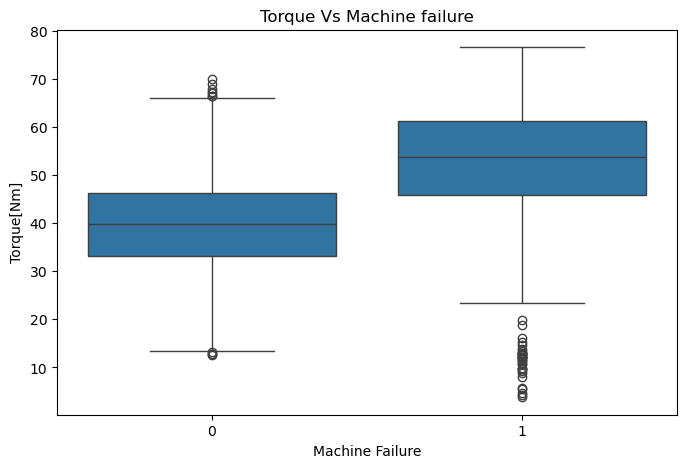

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data = df,x ='Machine failure',y='Torque [Nm]')
plt.title('Torque Vs Machine failure')
plt.xlabel('Machine Failure')
plt.ylabel('Torque[Nm]') 
plt.show()            

In [18]:
#Feature and Target Selection
x = df.drop('Machine failure',axis = True)
y = df['Machine failure']

In [30]:
#Encoding
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
print( x.select_dtypes(include = 'object').columns)
   

Index(['Type'], dtype='object')


In [32]:
x['Type'] = encoder.fit_transform(x['Type'])

In [33]:
#Train-Test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42,stratify = y)

In [34]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [23]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [36]:
#importing libraries
import tensorflow as tf
print(tf.__version__)
print(tf.keras)
print(tf.__file__)



2.21.0
<KerasLazyLoader>
C:\Users\janga\anaconda3\Lib\site-packages\tensorflow\__init__.py


In [37]:
#Build neural network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [38]:

model = Sequential([
       Dense(16,activation = 'relu'),
       Dense(8,activation = 'relu'),
       Dense(1,activation = 'sigmoid')
       ])
             

In [39]:

#compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [52]:
class_weight =  {0:1,1:5}

In [53]:
#Training and Validation Curves
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose =1,
    class_weight = class_weight
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9630 - loss: 0.2180 - val_accuracy: 0.9581 - val_loss: 0.1109
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9627 - loss: 0.2073 - val_accuracy: 0.9600 - val_loss: 0.1064
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9639 - loss: 0.2022 - val_accuracy: 0.9631 - val_loss: 0.1006
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9628 - loss: 0.2004 - val_accuracy: 0.9675 - val_loss: 0.0934
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9663 - loss: 0.1978 - val_accuracy: 0.9681 - val_loss: 0.0899
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9634 - loss: 0.1953 - val_accuracy: 0.9663 - val_loss: 0.0949
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9634 - loss: 0.1952 - val_accuracy: 0.9531 - val_loss: 0.1142
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9647 - loss: 0.1927 - val_accuracy: 0.

In [54]:
#Evaluation
test_loss,test_accuracy = model.evaluate(x_test,y_test,verbose = 1)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9600 - loss: 0.1036


In [55]:
print('Test Loss:',test_loss)
print('Accuracy:',test_accuracy)

Test Loss: 0.10359085351228714
Accuracy: 0.9599999785423279


In [56]:
#confusion matrix
from sklearn.metrics import confusion_matrix
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
print(cm)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[1873   59]
 [  21   47]]


In [57]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.44      0.69      0.54        68

    accuracy                           0.96      2000
   macro avg       0.72      0.83      0.76      2000
weighted avg       0.97      0.96      0.96      2000



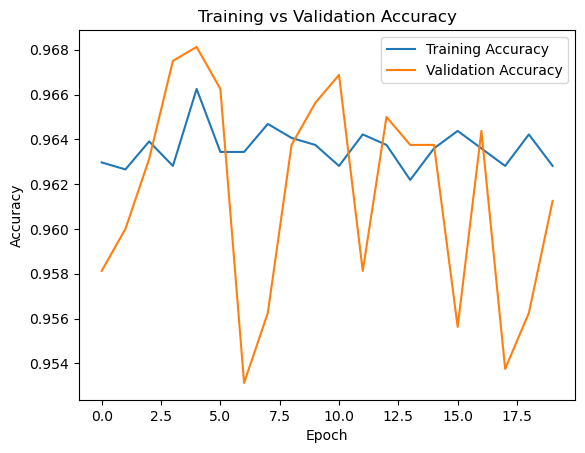

In [58]:

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

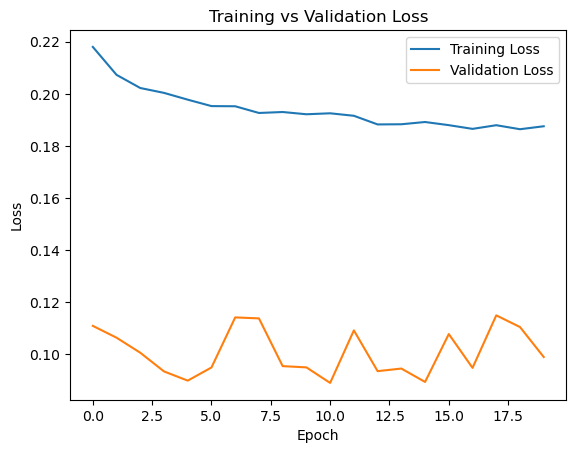

In [59]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [60]:
#data leakage
print(x.columns.tolist())

['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [61]:
print(df.columns.tolist())

['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']


In [63]:
#saving the final model
model.save("machine_failure_model.keras")
import joblib
joblib.dump(scaler,"machine_failure_scaler.pkl")

['machine_failure_scaler.pkl']

#Conclusion
A Dense neural network was developed for machine failure prediction.The model was evaluated using accuracy,
precision,recall,F1-score, and a confusion matrix.Because machine failures were the minority class,class weighting
was explored to improve detection of the failure class.The final model achieved improved failure recall compared with
the unweighted model